## Neural networks and deep learning

Learn about neural nets and build a model for classifying images of clothes

### Fashion Classification

Dataset:

- Full: https://github.com/alexeygrigorev/clothing-dataset
- Small: https://github.com/alexeygrigorev/clothing-dataset-small

Links:

- https://cs231n.github.io

## TensorFlow and Keras

- Installing TensorFlow
- Loading Images

In [1]:
# import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!git clone https://github.com/alexeygrigorev/clothing-dataset-small.git /content/drive/MyDrive/ml-projects/fashion-classification/data

fatal: destination path '/content/drive/MyDrive/ml-projects/fashion-classification/data' already exists and is not an empty directory.


In [4]:
BASE_PATH = "/content/drive/MyDrive/ml-projects/fashion-classification"
DATA_PATH = f"{BASE_PATH}/data/train/t-shirt"

In [5]:
name = "5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg"

full_name = f"{DATA_PATH}/{name}"

img = load_img(full_name, target_size=(299, 299))

## Pre-trained convolutional neural networks

- Imagenet dataset: https://www.image-net.org/
- Pre-trained models: https://keras.io/api/applications/

In [6]:
# use the pretrained model
model = Xception(weights="imagenet", input_shape=(299, 299, 3))


91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
x = np.array([img])

# use the preprocess input function use by the creators to preprocess the img
X = preprocess_input(x)

# predict the class of the image
pred = model.predict(X)

# use decode predictions to see the class of the image
decode_predictions(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n03595614', 'jersey', np.float32(0.68196356)),
  ('n02916936', 'bulletproof_vest', np.float32(0.038139977)),
  ('n04370456', 'sweatshirt', np.float32(0.034324735)),
  ('n03710637', 'maillot', np.float32(0.011354207)),
  ('n04525038', 'velvet', np.float32(0.0018453562))]]

*The actual class of the image is a shirt, but shirt as a class is not seen in image net, so the pretrained model would be adjusted to be an ideal model for our task of classifying the image*

## Convolutional Neural Network

- Types of layers
- Convolutional Layers and filters
- Dense layers

There are more layers. Read here: https://cs231n.github.io/

## Transfer learning

- Reading data with ImageDataGenerator
- Train Xception on smaller images (150 x 150)

In [8]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    f'{BASE_PATH}/data/train',
    target_size=(150,150),
    batch_size=32
)

Found 3068 images belonging to 10 classes.


In [9]:
## check the classes in the train dataset
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [10]:
X, y = next(train_ds)

In [11]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    f'{BASE_PATH}/data/validation',
    target_size=(150,150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


In [12]:
base_model = Xception(weights="imagenet", 
                      include_top=False, 
                      input_shape=(150, 150, 3))

# freeze convolutional layers
base_model.trainable=False

inputs = keras.Input(shape = (150, 150, 3))

base = base_model(inputs, training = False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
learning_rate = 0.01

optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
loss = keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy']
)

In [18]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 523s 5s/step - accuracy: 0.8070 - loss: 0.6418 - val_accuracy: 0.7390 - val_loss: 1.0147
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 146ms/step - accuracy: 0.8560 - loss: 0.4600 - val_accuracy: 0.7595 - val_loss: 0.9362
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 146ms/step - accuracy: 0.9045 - loss: 0.2708 - val_accuracy: 0.8065 - val_loss: 0.7575
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 143ms/step - accuracy: 0.9470 - loss: 0.1563 - val_accuracy: 0.7654 - val_loss: 1.0371
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 145ms/step - accuracy: 0.9262 - loss: 0.1818 - val_accuracy: 0.7683 - val_loss: 1.1575
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 143ms/step - accuracy: 0.9603 - loss: 0.1123 - val_accuracy: 0.7947 - val_loss: 0.9447
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.9785 - loss: 0.0675 - val_accuracy: 0.8182 - val_loss: 0.9489
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - accuracy: 0.9865 - loss: 0.0480 - val_accura

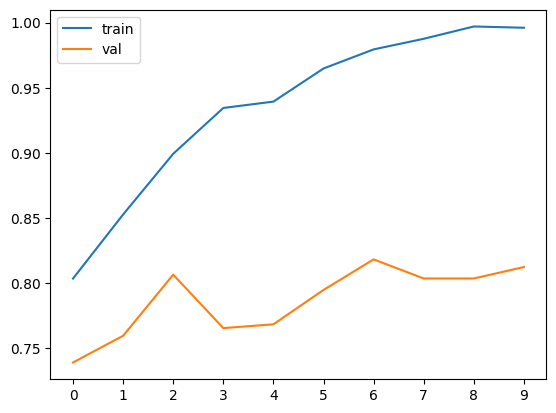

In [19]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

## Adjusting the learning rate

- What's the learning rate
- Trying different values

In [20]:
def make_model(learning_rate):
    base_model = Xception(weights="imagenet", 
                      include_top=False, 
                      input_shape=(150, 150, 3))

    # freeze convolutional layers
    base_model.trainable=False

    ##############################################

    inputs = keras.Input(shape = (150, 150, 3))

    base = base_model(inputs, training = False)

    vectors = keras.layers.GlobalAveragePooling2D()(base)

    outputs = keras.layers.Dense(10)(vectors)

    model = keras.Model(inputs, outputs)

    ##############################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [21]:
scores = {}
for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()

0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 36s 282ms/step - accuracy: 0.3125 - loss: 2.0728 - val_accuracy: 0.4956 - val_loss: 1.5775
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - accuracy: 0.5461 - loss: 1.4387 - val_accuracy: 0.6188 - val_loss: 1.2401
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 147ms/step - accuracy: 0.6403 - loss: 1.1338 - val_accuracy: 0.6804 - val_loss: 1.0644
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 143ms/step - accuracy: 0.6766 - loss: 1.0017 - val_accuracy: 0.7155 - val_loss: 0.9511
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 146ms/step - accuracy: 0.7144 - loss: 0.9052 - val_accuracy: 0.7331 - val_loss: 0.8778
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.7095 - loss: 0.8498 - val_accuracy: 0.7449 - val_loss: 0.8271
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 145ms/step - accuracy: 0.7462 - loss: 0.7961 - val_accuracy: 0.7654 - val_loss: 0.7868
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.7549 - loss: 0.7528 - v

*Plot the validation accuracy of the different learning rates*

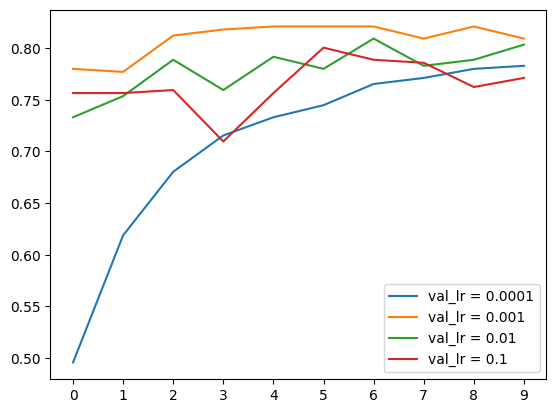

In [22]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val_lr = {lr}')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

*remove the learning rates with the worst performances*

In [23]:
del scores[0.0001]
del scores[0.1]

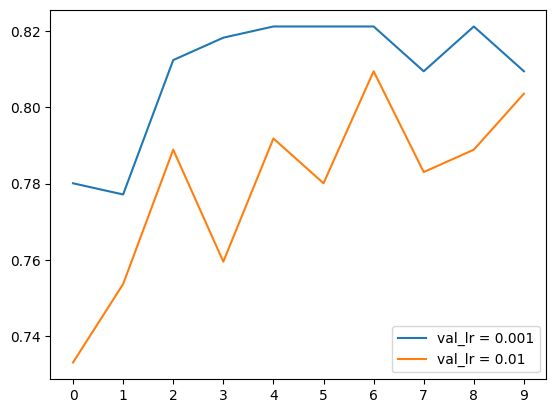

In [24]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val_lr = {lr}')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

*we will go with the learning rate of 0.001 since it is the best learning rate with the best validation scores*

## Checkpointing

- Savings the best model only
- Training a model with callbacks

In [25]:
BASE_PATH = "/content/drive/MyDrive/ml-projects/fashion-classification"
MODEL_PATH = os.path.join(BASE_PATH, "models")

os.makedirs(MODEL_PATH, exist_ok=True)

In [26]:
checkpoint = keras.callbacks.ModelCheckpoint(
    os.path.join(MODEL_PATH, 'xception_v1_{epoch:02d}_{val_accuracy:.3f}.keras'),
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

In [27]:
learning_rate = 0.001
model = make_model(learning_rate=0.001)
history = model.fit(
    train_ds, 
    epochs=10, 
    validation_data=val_ds, 
    callbacks=[checkpoint]
)


Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 36s 285ms/step - accuracy: 0.5332 - loss: 1.4370 - val_accuracy: 0.7654 - val_loss: 0.6947
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - accuracy: 0.8040 - loss: 0.6247 - val_accuracy: 0.7859 - val_loss: 0.6213
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - accuracy: 0.8276 - loss: 0.5105 - val_accuracy: 0.8152 - val_loss: 0.5669
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 147ms/step - accuracy: 0.8704 - loss: 0.4328 - val_accuracy: 0.8065 - val_loss: 0.5514
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.9015 - loss: 0.3546 - val_accuracy: 0.8123 - val_loss: 0.5374
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 146ms/step - accuracy: 0.9102 - loss: 0.3122 - val_accuracy: 0.8123 - val_loss: 0.5469
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 148ms/step - accuracy: 0.9159 - loss: 0.2932 - val_accuracy: 0.8240 - val_loss: 0.5316
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.9376 - loss: 0.2487 - val_accu

## Adding more layers

- Adding one inner dense layer
- Experimenting with different sizes of inner layer

In [28]:
def make_model(learning_rate, size_inner=100):
    base_model = Xception(weights="imagenet", 
                      include_top=False, 
                      input_shape=(150, 150, 3))

    # freeze convolutional layers
    base_model.trainable=False

    ##############################################

    inputs = keras.Input(shape = (150, 150, 3))

    base = base_model(inputs, training = False)

    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    outputs = keras.layers.Dense(10)(inner)

    model = keras.Model(inputs, outputs)

    ##############################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [29]:
learning_rate = 0.001

scores = {}

for size in [10, 100, 1000]:
    print(size)

    model = make_model(learning_rate=learning_rate, size_inner=size)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[size] = history.history

    print()
    print()

10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 283ms/step - accuracy: 0.4510 - loss: 1.6202 - val_accuracy: 0.7302 - val_loss: 0.8798
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 146ms/step - accuracy: 0.7407 - loss: 0.7987 - val_accuracy: 0.7683 - val_loss: 0.7122
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 148ms/step - accuracy: 0.8014 - loss: 0.6019 - val_accuracy: 0.7947 - val_loss: 0.6596
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 146ms/step - accuracy: 0.8555 - loss: 0.4625 - val_accuracy: 0.7390 - val_loss: 0.7191
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 145ms/step - accuracy: 0.8507 - loss: 0.4350 - val_accuracy: 0.7742 - val_loss: 0.6227
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 146ms/step - accuracy: 0.8953 - loss: 0.3663 - val_accuracy: 0.8299 - val_loss: 0.5594
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 146ms/step - accuracy: 0.9095 - loss: 0.2982 - val_accuracy: 0.8094 - val_loss: 0.5535
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 148ms/step - accuracy: 0.9364 - loss: 0.2611 - val_a

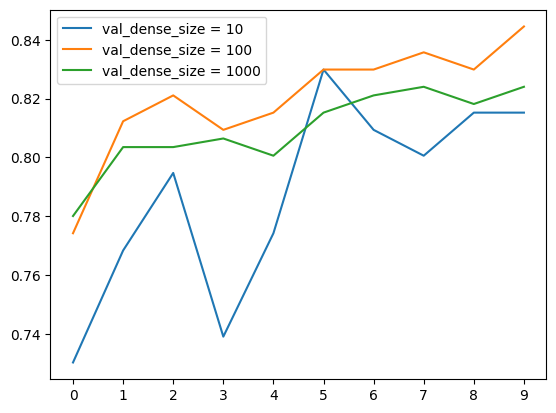

In [30]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val_dense_size = {size}')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

## Regularization and dropout

- Regularizing by freezing a part of the network
- Adding dropout to our model
- Experimenting with different values

In [31]:
def make_model(learning_rate, size_inner=100, droprate=0.5):
    base_model = Xception(weights="imagenet", 
                      include_top=False, 
                      input_shape=(150, 150, 3))

    # freeze convolutional layers
    base_model.trainable=False

    ##############################################

    inputs = keras.Input(shape = (150, 150, 3))

    base = base_model(inputs, training = False)

    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs, outputs)

    ##############################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [32]:
learning_rate = 0.001
size = 100

scores = {}

for droprate in [0.0, 0.2, 0.5, 0.8]:
    print(droprate)

    model = make_model(learning_rate=learning_rate, 
                       size_inner=size,
                       droprate=droprate)
    history = model.fit(train_ds, epochs=30, validation_data=val_ds)
    scores[droprate] = history.history

    print()
    print()

0.0
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 34s 272ms/step - accuracy: 0.5886 - loss: 1.2791 - val_accuracy: 0.8006 - val_loss: 0.6418
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step - accuracy: 0.8187 - loss: 0.5172 - val_accuracy: 0.7977 - val_loss: 0.6061
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 145ms/step - accuracy: 0.8863 - loss: 0.3653 - val_accuracy: 0.8065 - val_loss: 0.6016
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.9211 - loss: 0.2744 - val_accuracy: 0.7947 - val_loss: 0.6041
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.9542 - loss: 0.1755 - val_accuracy: 0.7977 - val_loss: 0.5958
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step - accuracy: 0.9770 - loss: 0.1181 - val_accuracy: 0.8211 - val_loss: 0.5761
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 145ms/step - accuracy: 0.9895 - loss: 0.0821 - val_accuracy: 0.8123 - val_loss: 0.6323
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.9957 - loss: 0.0559 - val_

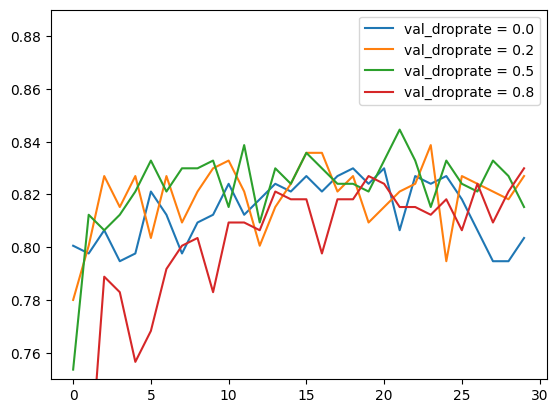

In [33]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val_droprate = {size}')

plt.ylim(0.75,0.89)
plt.legend()
plt.show()

## Data Augumentation

- Different Data Augumentation
- Training a model with augumentation
- How to select data augumentation

for more info on the above visit: [ML Zoomcamp Youtube](https://www.youtube.com/watch?v=aoPfVsS3BDE&list=PL3MmuxUbc_hIhxl5Ji8t4O6lPAOpHaCLR&index=78)

In [35]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input,
                               shear_range=10.0,
                               zoom_range=0.1,
                               vertical_flip=True)

train_ds = train_gen.flow_from_directory(
    f'{BASE_PATH}/data/train',
    target_size=(150,150),
    batch_size=32
)


val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    f'{BASE_PATH}/data/validation',
    target_size=(150,150),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [36]:
learning_rate = 0.001
size = 100
dropout = 0.2

scores = {}


model = make_model(learning_rate=learning_rate, 
                    size_inner=size,
                    droprate=dropout)
history = model.fit(train_ds, epochs=50, validation_data=val_ds)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 51s 449ms/step - accuracy: 0.4820 - loss: 1.5764 - val_accuracy: 0.7566 - val_loss: 0.7465
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 31s 317ms/step - accuracy: 0.6985 - loss: 0.8893 - val_accuracy: 0.7918 - val_loss: 0.6646
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 308ms/step - accuracy: 0.7215 - loss: 0.8222 - val_accuracy: 0.7801 - val_loss: 0.6368
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 311ms/step - accuracy: 0.7717 - loss: 0.6844 - val_accuracy: 0.7713 - val_loss: 0.6425
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 306ms/step - accuracy: 0.7805 - loss: 0.6318 - val_accuracy: 0.7830 - val_loss: 0.6094
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 310ms/step - accuracy: 0.8040 - loss: 0.5954 - val_accuracy: 0.8094 - val_loss: 0.5703
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 312ms/step - accuracy: 0.8043 - loss: 0.5633 - val_accuracy: 0.8094 - val_loss: 0.5888
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 312ms/step - accuracy: 0.8243 - loss: 0.5087 - val_accu

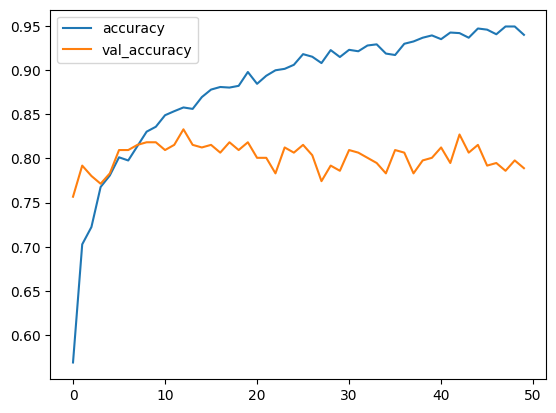

In [37]:
plt.plot(history.history['accuracy'], label = "accuracy")
plt.plot(history.history['val_accuracy'], label = "val_accuracy")
plt.legend()
plt.show()

Training a Larger Model
- Train a 299x299 model

In [38]:
def make_model(learning_rate=0.01, input_size = 150, size_inner=100, droprate=0.5):
    base_model = Xception(weights="imagenet", 
                      include_top=False, 
                      input_shape=(input_size, input_size, 3))

    # freeze convolutional layers
    base_model.trainable=False

    ##############################################

    inputs = keras.Input(shape = (input_size, input_size, 3))

    base = base_model(inputs, training = False)

    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs, outputs)

    ##############################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [42]:
input_size = 299

In [46]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input,
                               shear_range=10,
                               zoom_range=0.1,
                               horizontal_flip=True)

train_ds = train_gen.flow_from_directory(
    f'{BASE_PATH}/data/train',
    target_size=(input_size,input_size),
    batch_size=32
)


val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    f'{BASE_PATH}/data/validation',
    target_size=(input_size,input_size),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [47]:
checkpoint = keras.callbacks.ModelCheckpoint(
    os.path.join(MODEL_PATH, 'xception_v4_{epoch:02d}_{val_accuracy:.3f}.keras'),
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

In [ ]:
learning_rate = 0.0005
size = 100
dropout = 0.2

scores = {}


model = make_model(learning_rate=learning_rate, 
                   input_size=input_size,
                    size_inner=size,
                    droprate=dropout)
history = model.fit(train_ds, epochs=50, validation_data=val_ds, callbacks=[checkpoint])

## Using the model

- Loading the model
- Evaluating the model
- Getting Predictions

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img

from tensorflow.keras.applications.xception import preprocess_input

In [4]:
BASE_PATH = "/content/drive/MyDrive/ml-projects/fashion-classification"

In [6]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    f'{BASE_PATH}/data/test',
    target_size=(299,299),
    batch_size=32,
    shuffle=False
)

Found 372 images belonging to 10 classes.


In [8]:
model = keras.models.load_model(f'{BASE_PATH}/models/xception_v4_10_0.883.keras')

In [9]:
model.evaluate(test_ds)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 150s 10s/step - accuracy: 0.8629 - loss: 0.4483


[0.36824265122413635, 0.8897849321365356]

In [12]:
import os

MODEL_PATH = os.path.join(BASE_PATH, "data/test/pants/0dfec862-c49f-430b-a6ef-c7ceb187225e.jpg")

In [15]:
img = load_img(MODEL_PATH, target_size=(299, 299))

In [16]:
import numpy as np

X = np.array([img])
X.shape

(1, 299, 299, 3)

In [18]:
X = preprocess_input(X)

In [19]:
cat = ['dress',
 'hat',
 'longsleeve',
 'outwear',
 'pants',
 'shirt',
 'shoes',
 'shorts',
 'skirt',
 't-shirt'
]

In [35]:
pred = model.predict(X)

dict(zip(cat, pred[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


{'dress': np.float32(-4.0928617),
 'hat': np.float32(-10.703295),
 'longsleeve': np.float32(-6.2389975),
 'outwear': np.float32(-4.4894023),
 'pants': np.float32(17.641312),
 'shirt': np.float32(-6.042905),
 'shoes': np.float32(-13.432556),
 'shorts': np.float32(2.323951),
 'skirt': np.float32(-12.687801),
 't-shirt': np.float32(-10.692159)}